# Star Schema and Interactive Dashboard for Financial Transactions

## Part 1 - Data Warehouse Modeling: Star Schema
### 1.1 Define the Business Process and the Fact Grain

Business Process: The business process analyzed is the monitoring and recording of trading activities (securities purchase and sale operations) performed on a financial account throughout the 2024 calendar year. This process captures the full flow of asset acquisitions and disposals conducted by the user.

Fact Grain: The granularity of the Fact_Transactions table is set at the level of a single transaction. Each row in the **Fact_Transactions** table represents one transaction from the account statement file. It records a specific trade operation (BUY or SELL) executed at a precise point in time, for a specific stock (Symbol), with a defined quantity (Unit).


### 1.2 Identify Fact and Dimensions

In [16]:
import pandas as pd
import zipfile
import os

# Let's define the path to the zip file
zip_path = 'Datasets.zip'

# Let's extract the files to a temporary folder for convenient workwith zipfile.ZipFile(zip_path, 'r') as zip_ref:
with zipfile.ZipFile(zip_path, 'r') as zip_ref: 
    zip_ref.extractall('extracted_data')

# Now let's load the files into the DataFrames
df_transactions = pd.read_csv('extracted_data/account-statement-1-1-2024-12-31-2024.csv', sep=';')
df_symbols = pd.read_csv('extracted_data/symbols.csv', sep=';')
df_countries = pd.read_csv('extracted_data/country.csv')

# Quick check to see if everything is loaded correctly
print("Transactions loaded:", df_transactions.shape)
print("Symbols loaded:", df_symbols.shape)
print("Countries loaded:", df_countries.shape)

# We show the first few lines for safety
df_transactions.head()

Transactions loaded: (2745, 6)
Symbols loaded: (3194, 5)
Countries loaded: (249, 11)


,IDTransaction,Date,TransactionType,Symbol,Unit,Unnamed: 5
0,2.769834e+09,11/01/2024 10:44:03,BUY,BAP,1605.0,NaN
1,2.767325e+09,24/01/2024 08:07:24,SELL,BAP,1605.0,NaN
2,2.815474e+09,10/01/2024 11:00:08,SELL,BAP,914.0,NaN
3,2.622244e+09,16/01/2024 08:14:21,BUY,ACGL,646.0,NaN
4,2.629871e+09,16/01/2024 14:34:12,SELL,ALVO,646.0,NaN


| Type | Table |
|------|-------|
| Fact | `Fact_Transactions` |
| Dimension | `Dim_Time` |
| Dimension | `Dim_Geography` |
| Dimension | `Dim_Symbol` |
| Dimension | `Dim_TransactionType` |

In [17]:
# CREATE DIMENSION TABLES 

# A. Dim_Symbol: Create a catalog of companies with descriptive attributes.
# We drop duplicates to ensure each symbol is a unique dimension entry
dim_symbol = df_symbols[['symbol', 'company_name', 'sector', 'industry', 'country']].drop_duplicates().copy()
dim_symbol.rename(columns={'symbol': 'Symbol'}, inplace=True)
dim_symbol['Symbol_Key'] = range(1, len(dim_symbol) + 1)

# B. Dim_Geography: Create a catalog of countries and their regional hierarchies
# based on the country metadata provided in country.csv
dim_geography = df_countries[['name', 'alpha-2', 'sub-region', 'region']].drop_duplicates().copy()
dim_geography.rename(columns={
    'name': 'Country',
    'alpha-2': 'ISO_Code'  
}, inplace=True)
dim_geography['Geography_Key'] = range(1, len(dim_geography) + 1)

# C. Dim_Transaction_Type: Define static transaction categories
# we are mapping BUY/SELL actions to unique surrogate keys
dim_transaction_type = pd.DataFrame({'TransactionType': ['BUY', 'SELL']})
dim_transaction_type['Type_Key'] = range(1, len(dim_transaction_type) + 1)

# D. Dim_Time: Generate a time dimension (Calendar) from transaction dates.
# We extract hierarchical temporal features for multi-level analysis
df_transactions['Date_Parsed'] = pd.to_datetime(df_transactions['Date'], dayfirst=True)
unique_dates = df_transactions['Date_Parsed'].dt.date.unique()
dim_time = pd.DataFrame({'Date': unique_dates})
dim_time['Date_Key'] = range(1, len(dim_time) + 1)
dim_time['Year'] = pd.to_datetime(dim_time['Date']).dt.year
dim_time['Quarter'] = pd.to_datetime(dim_time['Date']).dt.quarter
dim_time['Month'] = pd.to_datetime(dim_time['Date']).dt.month
dim_time['Day'] = pd.to_datetime(dim_time['Date']).dt.day

print("\n--- DIM_SYMBOL (SYMBOLS) ---")
display(dim_symbol.head())

print("\n--- DIM_GEOGRAPHY (Geographic Hierarchy) ---")
display(dim_geography.head())

print("\n--- DIM_TRANSACTION_TYPE (Type of transaction) ---")
display(dim_transaction_type.head())

print("\n--- DIM_TIME (Calendar Hierarchy) ---")
display(dim_time.head())


--- DIM_SYMBOL (SYMBOLS) ---


,Symbol,company_name,sector,industry,country,Symbol_Key
0,TEAM,Atlassian Corporation,Technology,Software - Application,Australia,1
1,WDS,Woodside Energy Group Limited,Energy,Oil & Gas E&P,Australia,2
2,OSW,OneSpaWorld Holdings Limited,Consumer Cyclical,Leisure,Bahamas,3
3,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda,4
4,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty,Bermuda,5



--- DIM_GEOGRAPHY (Geographic Hierarchy) ---


,Country,ISO_Code,sub-region,region,Geography_Key
0,Afghanistan,AF,Southern Asia,Asia,1
1,Åland Islands,AX,Northern Europe,Europe,2
2,Albania,AL,Southern Europe,Europe,3
3,Algeria,DZ,Northern Africa,Africa,4
4,American Samoa,AS,Polynesia,Oceania,5



--- DIM_TRANSACTION_TYPE (Type of transaction) ---


,TransactionType,Type_Key
0,BUY,1
1,SELL,2



--- DIM_TIME (Calendar Hierarchy) ---


,Date,Date_Key,Year,Quarter,Month,Day
0,2024-01-11,1,2024.0,1.0,1.0,11.0
1,2024-01-24,2,2024.0,1.0,1.0,24.0
2,2024-01-10,3,2024.0,1.0,1.0,10.0
3,2024-01-16,4,2024.0,1.0,1.0,16.0
4,2024-01-30,5,2024.0,1.0,1.0,30.0


In [18]:
# CREATE FACT TABLE 

# Initialize the Fact table from the source transaction log
fact_transactions = df_transactions.copy()
fact_transactions['Date_Only'] = fact_transactions['Date_Parsed'].dt.date

# Merge dimensions to assign surrogate keys
# Merge Symbol to get the 'country' column needed for Geography
fact_transactions = fact_transactions.merge(dim_symbol, on='Symbol', how='left')

# Merge Geography using the country we just acquired
fact_transactions = fact_transactions.merge(dim_geography, left_on='country', right_on='Country', how='left')

# Merge Transaction Type and Time
fact_transactions = fact_transactions.merge(dim_transaction_type, on='TransactionType', how='left')
fact_transactions = fact_transactions.merge(dim_time, left_on='Date_Only', right_on='Date', how='left')

# Final selection: Keep only the surrogate keys and the transaction measure (Unit)
fact_transactions = fact_transactions[[
    'IDTransaction', 'Date_Key', 'Symbol_Key', 'Geography_Key', 
    'Type_Key', 'Unit'
]]
print("\n--- FACT_TRANSACTIONS (Core Data Warehouse Table) ---")
display(fact_transactions.head())


--- FACT_TRANSACTIONS (Core Data Warehouse Table) ---


,IDTransaction,Date_Key,Symbol_Key,Geography_Key,Type_Key,Unit
0,2.769834e+09,1,284.0,175.0,1.0,1605.0
1,2.767325e+09,2,284.0,175.0,2.0,1605.0
2,2.815474e+09,3,284.0,175.0,2.0,914.0
3,2.622244e+09,4,4.0,25.0,1.0,646.0
4,2.629871e+09,4,258.0,131.0,2.0,646.0


### 1.3 Define Dimension Hierarchies

To support multi-level analytical queries, the following hierarchies have been defined within the dimension tables:

**Dim_Time**: The temporal hierarchy allows for aggregation at different granularities, facilitating trend analysis over time:

Day → Month → Quarter → Year

**Dim_Geography**: This hierarchy allows regional performance analysis based on the geographical origin of the securities:

Country → Sub-Region → Region

**Dim_Symbol**: The industry classification hierarchy allows for thematic portfolio analysis and sectoral breakdown:

Industry → Sector

**Dim_TransactionType**: No formal hierarchy is applicable, as this is a flat dimension defining the type of transaction (BUY/SELL).

### 1.4 Design the Star Schema

The Star Schema has been implemented by establishing a central Fact table surrounded by normalized Dimension tables, connected via surrogate keys:

**Surrogate Keys (Dimensions)**:
Each dimension table includes a unique surrogate key (Date_Key, Symbol_Key, Geography_Key, Type_Key) to ensure efficient indexing and independence from source system primary keys.

**Fact Table Foreign Keys**:
The Fact_Transactions table acts as the core of the schema, containing these surrogate keys as foreign keys to maintain referential integrity with all dimensions.

**Measures and Descriptive Attributes**:

Measures: The Unit field in Fact_Transactions represents the quantitative measure for analysis.

Descriptive Attributes: All qualitative data (e.g., Company Name, Region, Industry) has been moved to the respective dimension tables, ensuring the Fact table remains lean and optimized for aggregation.


**Fact_Transactions**
- `IDTransaction` (PK, surrogate) (varchar)
- `Date_key` (FK → Dim_Time) (int)
- `Symbol_Key` (FK → Dim_Symbol) (int)
- `Geography_Key` (FK → Dim_Geography) (int)
- `Type_Key` (FK → Dim_Transaction_Type) (int)
- `Unity` (measure) (float)

**Dim_Time** 
- `Date_Key` (PK, surrogate) (int)
- `Date`(date)
- `Year`(int)
- `Quarter` (int)
- `Month` (int)
- `Day`(int)

**Dim_Symbol** 
- `Symbol_Key`(PK, surrogate) (int)
- `Symbol` (varchar)
- `Company_name` (varchar)
- `Sector` (varchar)
- `Industry` (varchar)
- `Country` (varchar)

**Dim_Geography** 
- `Geography_Key` (PK, surrogate) (int)
- `Country` (varchar)
- `ISO_Code` (varchar)
- `Sub-Region` (varchar)
- `Region` (varchar)

**Dim_TransactionType** 
- `Type_Key` (PK, surrogate) (int)
- `TransactionType` (varchar)

## Part 2 - Data Transformation and Analysis

# 2.1 Load and Clean the Data

In [19]:
# Data Cleaning: Removing unused attributes
# We keep only the columns explicitly required by our Star Schema design
dim_symbol_clean = dim_symbol[['Symbol_Key', 'Symbol', 'company_name', 'sector', 'industry', 'country']].copy()
dim_geography_clean = dim_geography[['Geography_Key', 'Country', 'sub-region', 'region']].copy()

# Data Quality: Check for missing values
print("--- Data Quality: Missing Values Check ---")
print("Transactions missing values:\n", df_transactions.isnull().sum())

# Data Integrity: Verify relationships (Referential Integrity)
# Verify all transaction symbols exist in the symbols dataset
missing_symbols = fact_transactions[~fact_transactions['Symbol_Key'].isin(dim_symbol_clean['Symbol_Key'])]
if missing_symbols.empty:
    print("\n[OK] All transaction symbols are mapped to the symbols dataset.")
else:
    print(f"\n[WARNING] {len(missing_symbols)} transactions have symbols not present in the catalog.")

# Verify all country mappings
missing_countries = fact_transactions[~fact_transactions['Geography_Key'].isin(dim_geography_clean['Geography_Key'])]
if missing_countries.empty:
    print("[OK] All company countries are mapped to the country dataset.")
else:
    print(f"[WARNING] {len(missing_countries)} transactions have unmapped countries.")

# Final verification of datasets
print("\n--- Final Cleaned Datasets Sample ---")
display(dim_symbol_clean.head())
display(dim_geography_clean.head())

--- Data Quality: Missing Values Check ---
Transactions missing values:
 IDTransaction       464
Date                464
TransactionType     464
Symbol              464
Unit                464
Unnamed: 5         2745
Date_Parsed         464
dtype: int64

[WARNING] 676 transactions have symbols not present in the catalog.
[WARNING] 770 transactions have unmapped countries.

--- Final Cleaned Datasets Sample ---


,Symbol_Key,Symbol,company_name,sector,industry,country
0,1,TEAM,Atlassian Corporation,Technology,Software - Application,Australia
1,2,WDS,Woodside Energy Group Limited,Energy,Oil & Gas E&P,Australia
2,3,OSW,OneSpaWorld Holdings Limited,Consumer Cyclical,Leisure,Bahamas
3,4,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda
4,5,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty,Bermuda


,Geography_Key,Country,sub-region,region
0,1,Afghanistan,Southern Asia,Asia
1,2,Åland Islands,Northern Europe,Europe
2,3,Albania,Southern Europe,Europe
3,4,Algeria,Northern Africa,Africa
4,5,American Samoa,Polynesia,Oceania


### 2.2 Analytical Questions

--- TOP 5 SECTORS BY SELL TRANSACTIONS IN US (2024) ---


,sector,IDTransaction
6,Technology,158
0,Communication Services,58
3,Financial Services,55
4,Healthcare,50
1,Consumer Cyclical,48


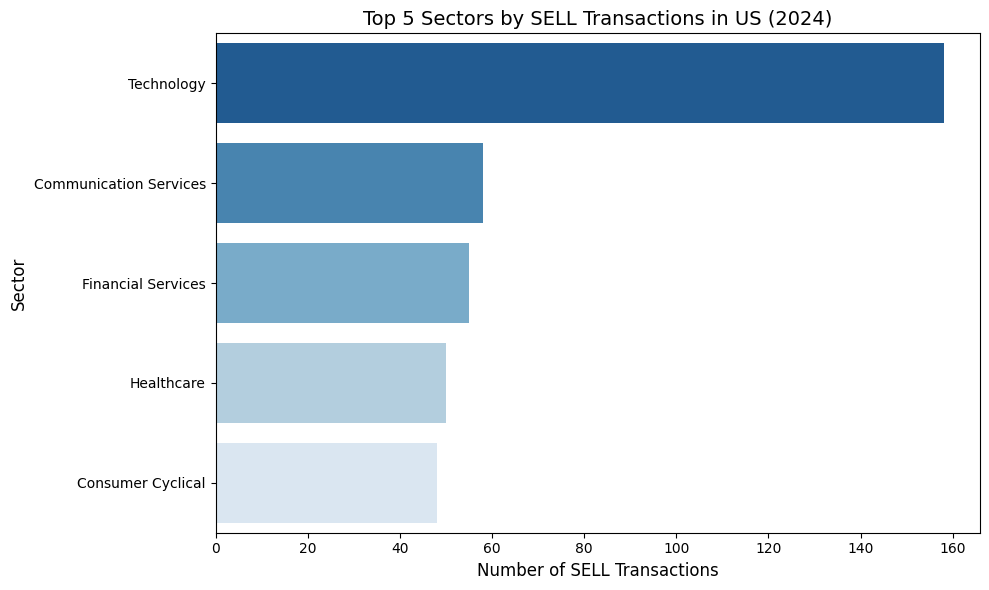

In [20]:
# QUERY 1: Top 5 sectors by number of SELL transactions in US during 2024

# Start from fact_transactions and JOIN with dimensions to get the descriptive attributes
# We perform the merge ON THE FLY
q1_df = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                         .merge(dim_geography, on='Geography_Key') \
                         .merge(dim_transaction_type, on='Type_Key') \
                         .merge(dim_time, on='Date_Key')

# Filter: Only 'SELL', 'US' and year 2024
q1_filtered = q1_df[
    (q1_df['TransactionType'] == 'SELL') & 
    (q1_df['Country'] == 'United States of America') & 
    (q1_df['Year'] == 2024)
]

# Group by sector and count the number of transactions
q1_result = q1_filtered.groupby('sector')['IDTransaction'].count().reset_index()

# Extract the Top 5
q1_top5 = q1_result.nlargest(5, 'IDTransaction')

# --- OUTPUT GENERATION (Table + Chart) ---

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Print a clean title and display the formatted table
print("--- TOP 5 SECTORS BY SELL TRANSACTIONS IN US (2024) ---")
display(q1_top5)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 6))

# Assign 'sector' to 'hue' and set 'legend=False' to avoid Seaborn deprecation warnings
ax = sns.barplot(data=q1_top5, x='IDTransaction', y='sector', hue='sector', palette='Blues_r', legend=False)

plt.title('Top 5 Sectors by SELL Transactions in US (2024)', fontsize=14)
plt.xlabel('Number of SELL Transactions', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.tight_layout()

plt.show()

--- TOP 5 SECTORS BY TOTAL UNITS TRADED IN Q3 (2024) ---


,sector,Unit
8,Technology,4461.0
6,Healthcare,3572.0
2,Consumer Cyclical,2667.0
5,Financial Services,2054.0
1,Communication Services,1863.0


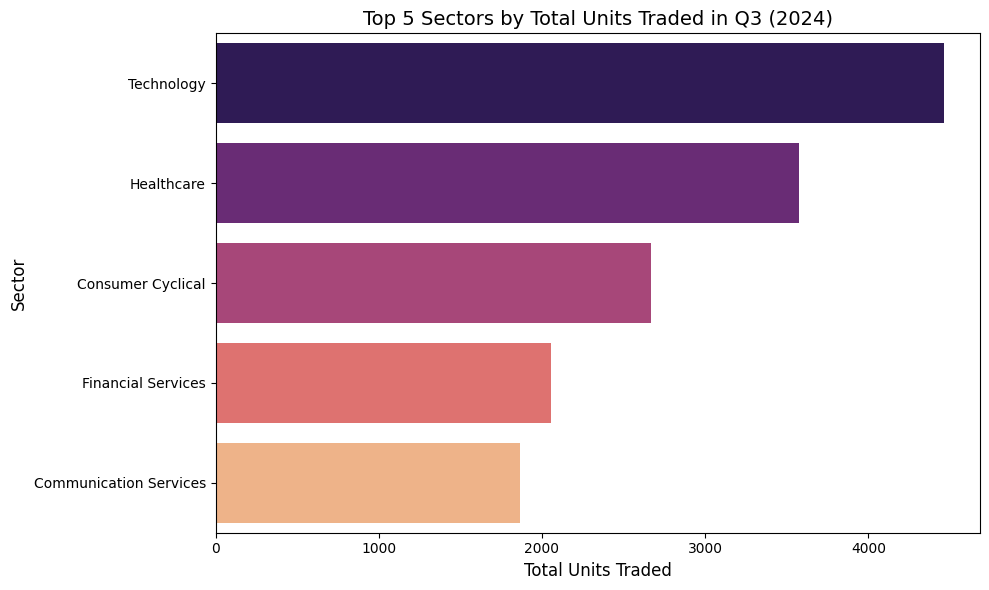

In [21]:
# QUERY 6: Top 5 sectors by total units traded (BUY + SELL) in Q3 of 2024

# Join the Fact Table with the necessary Dimensions
q6_df = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                         .merge(dim_transaction_type, on='Type_Key') \
                         .merge(dim_time, on='Date_Key')

# Filter: Only 'BUY' or 'SELL' transactions, Year 2024, and Quarter 3 (Q3)
# Note: Assumes your dim_time table uses the number 3 for Q3
q6_filtered = q6_df[
    (q6_df['TransactionType'].isin(['BUY', 'SELL'])) & 
    (q6_df['Year'] == 2024) & 
    (q6_df['Quarter'] == 3)
]

# Group by sector and sum the total units
q6_result = q6_filtered.groupby('sector')['Unit'].sum().reset_index()

# Ranking: Get the top 5
q6_top5 = q6_result.nlargest(5, 'Unit')


# --- OUTPUT GENERATION (Table + Chart) ---

# Print a clean title and display the formatted table
print("--- TOP 5 SECTORS BY TOTAL UNITS TRADED IN Q3 (2024) ---")
display(q6_top5)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 6))

# Assign 'sector' to 'hue' and set 'legend=False' to avoid Seaborn deprecation warnings
ax = sns.barplot(data=q6_top5, x='Unit', y='sector', hue='sector', palette='magma', legend=False)

plt.title('Top 5 Sectors by Total Units Traded in Q3 (2024)', fontsize=14)
plt.xlabel('Total Units Traded', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.tight_layout()

# Show the plot cleanly
plt.show()

--- TOP 5 COUNTRIES BY UNITS TRADED (FINANCIAL SERVICES) ---


,Country,Unit
5,United States of America,7352.0
3,Peru,4434.0
0,Bermuda,3658.0
2,China,1663.0
1,Canada,1466.0


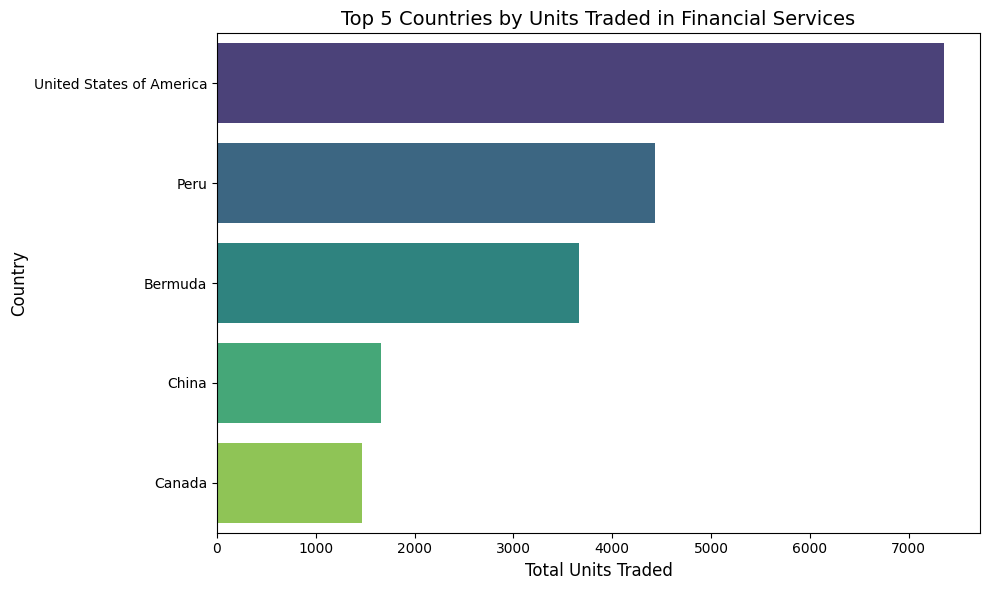

In [22]:
# QUERY 8: Top 5 countries by number of units traded in Financial Services companies

# Join the Fact Table with the necessary Dimensions
q8_df = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                         .merge(dim_geography, on='Geography_Key')

# Filter: Only the 'Financial Services' sector
q8_filtered = q8_df[q8_df['sector'].str.contains('Financial', case=False, na=False)]

# Group by country and sum the total units traded
q8_result = q8_filtered.groupby('Country')['Unit'].sum().reset_index()

# Ranking: Get the top 5
q8_top5 = q8_result.nlargest(5, 'Unit')


# --- OUTPUT GENERATION (Table + Chart) ---

# Print a clean title and display the formatted table
print("--- TOP 5 COUNTRIES BY UNITS TRADED (FINANCIAL SERVICES) ---")
display(q8_top5)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 6))

# Assign 'Country' to 'hue' and set 'legend=False' to avoid Seaborn deprecation warnings
ax = sns.barplot(data=q8_top5, x='Unit', y='Country', hue='Country', palette='viridis', legend=False)

plt.title('Top 5 Countries by Units Traded in Financial Services', fontsize=14)
plt.xlabel('Total Units Traded', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()

# Show the plot cleanly
plt.show()

--- TOP 5 COMPANIES BY AVERAGE UNITS PER TRANSACTION (Q2) ---


,company_name,Average_Units_Per_Transaction
63,Paysafe Limited,248.333333
41,HANGZHOU TIGERMED CONSULTING CO,208.500000
7,Alvotech,206.500000
12,Arch Capital Group Ltd.,206.500000
22,CNH Industrial N.V.,179.333333


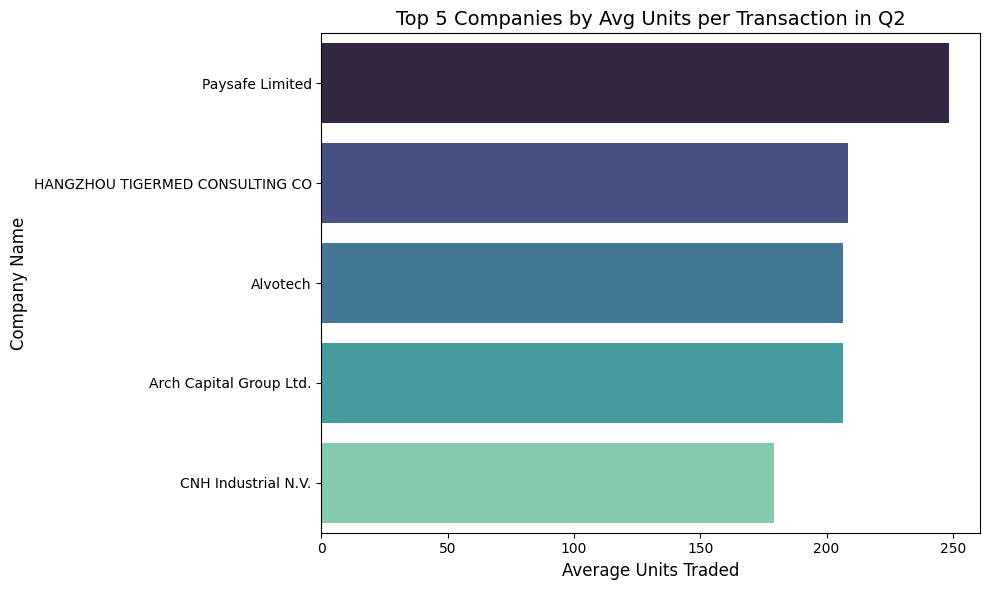

In [ ]:
# QUERY 10: Top 5 companies with the highest average units per transaction in Q2

# Join the Fact Table with the necessary Dimensions
q10_df = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                          .merge(dim_time, on='Date_Key')

# Filter: Only Quarter 2 (Q2)
q10_filtered = q10_df[q10_df['Quarter'] == 2]

# Group by company name and calculate the average (mean) of units
q10_result = q10_filtered.groupby('company_name')['Unit'].mean().reset_index()

# Let's rename the column to make the output clearer
q10_result.rename(columns={'Unit': 'Average_Units_Per_Transaction'}, inplace=True)

# Ranking: Get the top 5
q10_top5 = q10_result.nlargest(5, 'Average_Units_Per_Transaction')


# --- OUTPUT GENERATION (Table + Chart) ---

# Print a clean title and display the formatted table
print("--- TOP 5 COMPANIES BY AVERAGE UNITS PER TRANSACTION (Q2) ---")
display(q10_top5)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=q10_top5, 
    x='Average_Units_Per_Transaction', 
    y='company_name', 
    hue='company_name', 
    palette='mako', 
    legend=False
)

plt.title('Top 5 Companies by Avg Units per Transaction in Q2', fontsize=14)
plt.xlabel('Average Units Traded', fontsize=12)
plt.ylabel('Company Name', fontsize=12)
plt.tight_layout()

# Show the plot cleanly
plt.show()

--- TOP 5 REGIONS BY DISTINCT INDUSTRIES TRADED ---


,region,Distinct_Industries_Count
0,Americas,38
2,Europe,26
1,Asia,9


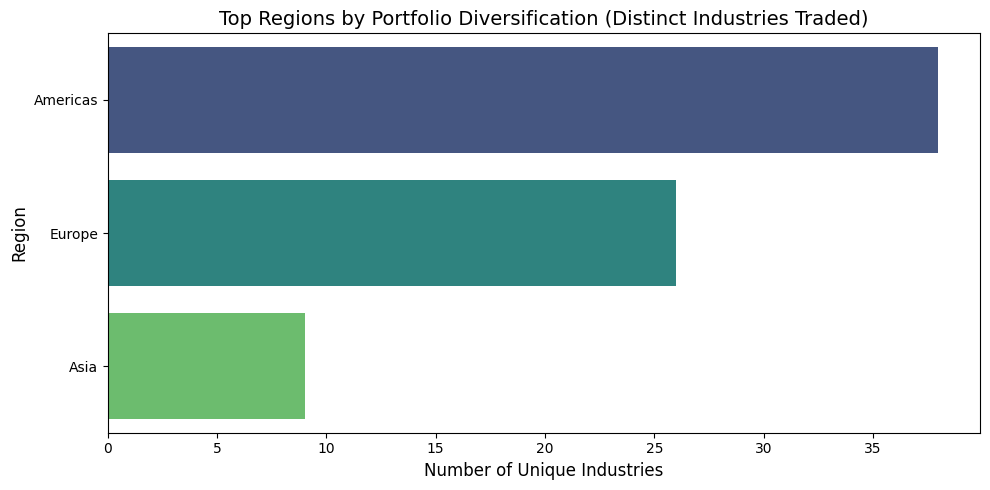

In [24]:
# QUERY 13: Top 5 regions by number of distinct industries traded

# Join the Fact Table with the necessary Dimensions
q13_df = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                          .merge(dim_geography, on='Geography_Key')

# Group by Region and count DISTINCT industries
q13_result = q13_df.groupby('region')['industry'].nunique().reset_index()

# Rename column for clarity
q13_result.rename(columns={'industry': 'Distinct_Industries_Count'}, inplace=True)

# Ranking: Get the top 5
q13_top5 = q13_result.nlargest(5, 'Distinct_Industries_Count')


# --- OUTPUT GENERATION (Table + Chart) ---

# Print a clean title and display the formatted table
print("--- TOP 5 REGIONS BY DISTINCT INDUSTRIES TRADED ---")
display(q13_top5)

# Generate the horizontal bar chart
plt.figure(figsize=(10, 5))

# Using 'mako' palette for a professional dark-to-light gradient that stays legible
ax = sns.barplot(
    data=q13_top5, 
    x='Distinct_Industries_Count', 
    y='region', 
    hue='region', 
    palette='viridis', 
    legend=False
)

plt.title('Top Regions by Portfolio Diversification (Distinct Industries Traded)', fontsize=14)
plt.xlabel('Number of Unique Industries', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()

# Show the plot cleanly
plt.show()

## PART 3 - Streamlit Dashboard
### Time Analysis

In [25]:
# =========================================================
# EXPORT DATA FOR STREAMLIT DASHBOARD
# =========================================================
print("Preparing data for the Dashboard...")

# Merge the fact table with all dimensions to create a comprehensive dataset
full_data = fact_transactions.merge(dim_symbol, on='Symbol_Key') \
                             .merge(dim_geography, on='Geography_Key') \
                             .merge(dim_transaction_type, on='Type_Key') \
                             .merge(dim_time, on='Date_Key')

# Save the unified dataset to a CSV file for the Streamlit app
full_data.to_csv('dashboard_data.csv', index=False)
print("Data successfully exported to 'dashboard_data.csv'!")

Preparing data for the Dashboard...
Data successfully exported to 'dashboard_data.csv'!
